# pyTOST demonstration notebook

This notebook demonstrates **equivalence testing (TOST)** for paired differences under several dependence structures:
IID, cluster, temporal, spatial, and spatiotemporal.

The goal is to show how **dependence assumptions change the standard error, confidence interval (CI), and TOST conclusion**,
and to provide practical “starting-point” configurations for each engine.


## 0) What pyTOST does and what this notebook does

### Package purpose (pyTOST)
Given paired outcomes (A vs B) summarized as a **paired difference** `diff = B − A`, pyTOST:
- estimates the mean difference \(\mu\),
- computes an uncertainty interval for \(\mu\) that is appropriate for the assumed dependence structure, and
- performs **TOST** for one or more equivalence margins \(\Delta\) (i.e., tests whether \(|\mu| < \Delta\) with controlled Type I error).

### Notebook purpose (this demo)
This notebook:
1. generates a small synthetic **spatiotemporal** dataset with realistic dependence,
2. runs each engine with comparable settings,
3. adds a dependence-appropriate **bootstrap sanity check** CI where feasible, and
4. visualizes how each engine’s CI changes.

If you are new to the package, read the “Engines” section first and then skim the code.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

from pyTOST import (
    run_tost,
    WorkflowOptions,
    SpatialConfig,
    SpatioTemporalConfig,
)

from pyTOST.data_gen.params_io import load_params, kwargs_for, validate_required_kwargs
from pyTOST.data_gen.synthetic_tost_data import generate_spatiotemporal

from pyTOST.bootstrap import (
    cluster_bootstrap,
    iid_bootstrap_ci_mean,
    moving_block_bootstrap_ci_mean,
    spatial_block_bootstrap,
)


In [2]:
# Notebook-wide constants

ALPHA = 0.05
DELTA = 1.0
MARGINS = [DELTA]
SEED = 123
BOOT_B = 500

### Helpers

In [3]:
def to_diff_df(df_long: pd.DataFrame, keep_cols=None) -> pd.DataFrame:
    keep_cols = keep_cols or []
    id_col, arm_col, y_col = "sample_id", "arm", "y"
    meta = df_long[[id_col] + [c for c in keep_cols if c in df_long.columns]].drop_duplicates(subset=[id_col])
    wide = df_long.pivot(index=id_col, columns=arm_col, values=y_col)
    out = meta.merge(wide, left_on=id_col, right_index=True, how="inner")
    out["diff"] = out["B"].astype(float) - out["A"].astype(float)
    return out.reset_index(drop=True)


In [4]:
def stack_primary(engine_name: str, res: dict) -> pd.DataFrame:
    dfp = res["primary"].copy()
    dfp["engine"] = engine_name
    return dfp

In [5]:
def add_bootstrap_to_primary(dfp: pd.DataFrame, ci_boot: tuple[float, float], boot_method_label: str = "Bootstrap CI"):
    """Attach bootstrap CI to a primary result table, with bounds normalized."""
    lo, hi = float(ci_boot[0]), float(ci_boot[1])
    lo, hi = (min(lo, hi), max(lo, hi))
    out = dfp.copy()
    out["boot_ci_low"] = lo
    out["boot_ci_high"] = hi
    out["boot_method"] = boot_method_label
    return out

In [6]:
def combine_and_display(tables: list[pd.DataFrame], title: str):
    """Streamlined output: decisions by Δ and CI summary (analytic + bootstrap)."""
    comb = pd.concat(tables, ignore_index=True)

    # Panel A: delta-level decisions (primary analytic CI)
    panel_a = (
        comb[["delta", "engine", "method", "equivalent"]]
        .drop_duplicates()
        .sort_values(["delta", "engine"])
        .reset_index(drop=True)
    )

    # Panel B: CI summary, where bootstrap is treated as its own 'method'
    analytic = comb[["engine", "method", "ci_low", "ci_high"]].drop_duplicates()
    bootstrap = (
        comb[["engine", "boot_method", "boot_ci_low", "boot_ci_high"]]
        .drop_duplicates()
        .rename(columns={"boot_method": "method", "boot_ci_low": "ci_low", "boot_ci_high": "ci_high"})
    )
    panel_b = (
        pd.concat([analytic, bootstrap], ignore_index=True)
        .sort_values(["engine", "method"])
        .reset_index(drop=True)
    )

    print("\n" + "="*100)
    print(title)
    print("="*100)
    print("\nDecisions by Δ (analytic CI)")
    display(panel_a)
    print("\nCI summary (analytic + bootstrap)")
    display(panel_b)

    return comb, panel_a, panel_b

In [7]:

def plot_ci_compare_delta1(
    comb: pd.DataFrame,
    title: str,
    delta: float = 1.0,
    use_bootstrap: bool = True,
):
    """Plot CI comparisons for a single margin Δ across engines.

    Parameters
    ----------
    comb:
        Combined results table returned by `combine_and_display(...)`.
    title:
        Figure title prefix.
    delta:
        Equivalence margin Δ to plot.
    use_bootstrap:
        If True and bootstrap CI columns exist, plot bootstrap CIs alongside analytic/model-based CIs.
    """
    sub = comb[comb["delta"] == float(delta)].copy()
    if sub.empty:
        raise ValueError(f"No rows for delta={delta} in comb.")

    engines = sub["engine"].unique().tolist()
    x = np.arange(len(engines))

    # Analytic/model-based CI
    mu = sub.groupby("engine")["mu_hat"].first().reindex(engines).to_numpy(float)
    lo = sub.groupby("engine")["ci_low"].first().reindex(engines).to_numpy(float)
    hi = sub.groupby("engine")["ci_high"].first().reindex(engines).to_numpy(float)
    yerr_lo = np.maximum(mu - lo, 0.0)
    yerr_hi = np.maximum(hi - mu, 0.0)

    plt.figure(figsize=(10.5, 4.2))
    plt.errorbar(
        x - 0.10,
        mu,
        yerr=[yerr_lo, yerr_hi],
        fmt="o",
        capsize=3,
        label="Analytic CI",
    )

    # Bootstrap sanity-check CI (if present)
    if use_bootstrap and ("boot_ci_low" in sub.columns) and ("boot_ci_high" in sub.columns):
        blo = sub.groupby("engine")["boot_ci_low"].first().reindex(engines).to_numpy(float)
        bhi = sub.groupby("engine")["boot_ci_high"].first().reindex(engines).to_numpy(float)
        blo, bhi = np.minimum(blo, bhi), np.maximum(blo, bhi)
        byerr_lo = np.maximum(mu - blo, 0.0)
        byerr_hi = np.maximum(bhi - mu, 0.0)
        plt.errorbar(
            x + 0.10,
            mu,
            yerr=[byerr_lo, byerr_hi],
            fmt="o",
            capsize=3,
            label="Bootstrap CI",
        )

    # Equivalence band and zero reference
    plt.axhline(+delta, linestyle="--")
    plt.axhline(-delta, linestyle="--")
    plt.axhline(0.0, linewidth=1.0)

    # Prevent label collisions: wrap long labels + slight rotation.
    def _wrap_label(s: str, width: int = 14) -> str:
        return "\n".join(textwrap.wrap(str(s), width=width)) if len(str(s)) > width else str(s)

    labels = [_wrap_label(s, width=16) for s in engines]
    plt.xticks(x, labels, rotation=20, ha="right")

    plt.ylabel("Mean difference (μ) and CI")
    plt.title(title + f" (Δ={delta})")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Bootstrap sanity checks used in this notebook

Where possible, we compute a bootstrap CI for the mean as a **sanity check** against the analytic (or model-based) CI.

- **IID**: row bootstrap of `diff`.
- **Cluster**: cluster bootstrap over `building_id` (resampling entire clusters).
- **Temporal**: moving-block bootstrap over time (block length chosen conservatively).
- **Spatial**: building bootstrap (resample buildings) as a practical approximation.
- **SpatioTemporal**: uses either (a) the engine’s parametric bootstrap CI, or (b) a Wald CI depending on configuration.

These bootstraps are not intended to be the final inference method; they are meant to flag gross mismatch between analytic
standard errors and empirical sampling variability under dependence.


## 1) Engines (conceptual overview)

All engines target the **same estimand** (the mean paired difference \(\mu\)).
They differ only in how they estimate the **standard error** of \(\hat\mu\) (and thus the CI and TOST conclusion).

Each engine section below uses the same structure:
- *What the engine assumes / models*
- *When you should use it*
- *Suggested starting options*
- *How this notebook calls it*


The engines demonstrated below are:

- **IID**: independent rows (baseline; often optimistic under dependence).
- **Cluster**: cluster-robust mean (arbitrary within-cluster dependence).
- **Temporal**: serial dependence via HAC variance.
- **Spatial**: Matérn spatial covariance (GLS/REML).
- **SpatioTemporal**: joint space–time covariance (separable AR(1) ⊗ Matérn when feasible).


### IID engine

**What it models**  
Assumes row-wise independence: \(\operatorname{Cov}(\varepsilon_i, \varepsilon_j)=0\) for \(i\neq j\).

**When to use**  
- As a fast baseline.
- When dependence is negligible relative to sampling noise.

**Suggested starting options**  
- `alpha=0.05` (CI level is \(1-2\alpha\)).
- Use `options=WorkflowOptions(do_sensitivity=False, bootstrap_B=0)` for fast analytic output.
- If you suspect mild heteroskedasticity, enable sensitivity checks via `do_sensitivity=True`.

**Notes**  
If the IID CI is much tighter than a dependence-aware bootstrap CI, IID is likely overconfident.


### Cluster engine

**What it models**  
Rows are independent **across clusters**, but potentially dependent **within** a cluster (e.g., repeated measurements within a building).

**When to use**  
- You have repeated observations per site/building/customer and want robust inference for the mean without specifying a full covariance model.

**Suggested starting options**  
- `cluster="building_id"` (or your grouping column).
- If you have very few clusters (rule of thumb: < 20), expect wider intervals and prefer a cluster bootstrap sanity check.

**Notes**  
This engine is typically conservative when within-cluster dependence is strong.


### Temporal engine

**What it models**  
Serial dependence over time using a HAC (Newey–West style) variance for \(\hat\mu\).

**When to use**  
- Measurements are ordered in time and exhibit autocorrelation (hourly/daily panels, sensor readings, etc.).
- Spatial structure is weak or secondary.

**Suggested starting options**  
- `time="time"` (your time index column).
- Use the optimized HAC/lag settings from `best_temporal_params.json` (as shown in the synthetic optimization notebooks).
- For bootstrapping, use a moving-block bootstrap with a block length reflecting the correlation length.

**Notes**  
If autocorrelation is long-range, choose a larger lag/block length to avoid overconfidence.


### Spatial engine

**What it models**  
Within each cluster/building, models spatial dependence with a Matérn covariance and fits via GLS/REML (then constructs a CI for \(\mu\)).

**When to use**  
- You have coordinates and expect spatial correlation (e.g., rooftop points, geospatial sampling).
- You want a parametric spatial covariance model rather than only cluster-robust inference.

**Suggested starting options**  
- `x="x"`, `ycoord="y"` (your coordinate columns).
- `spatial_config=SpatialConfig(nu_grid=(0.5, 1.5, 2.5), per_building_nugget=True, verbose_diagnostics=False)`

**Notes**  
On tiny samples, LR-based intervals can be numerically fragile; compare to a building bootstrap sanity check.


### SpatioTemporal engine

**What it models**  
Joint dependence in space and time. In the balanced case, fits a separable model (conceptually \(\text{AR(1)} \otimes \text{Matérn}\)).
If the panel is not balanced, it may fall back to per-time spatial fits aggregated via inverse-variance weighting.

**When to use**  
- You have both coordinates and time and expect correlation in both dimensions.
- You want the most dependence-aware standard error for \(\hat\mu\).

**Suggested starting options**  
- Start with `SpatioTemporalConfig()` defaults and **parametric bootstrap CI** (`mu_ci_method="parametric_bootstrap"`).
- If you need speed, use `mu_ci_method="wald"` and keep `joint_regularize=True` for stability.

**Notes**  
If the spatiotemporal CI is much wider than spatial-only or temporal-only, that is often real: the effective sample size can be much smaller under joint dependence.


> **Runtime note:** The spatiotemporal engine can be computationally heavy (joint covariance fit + optional parametric bootstrap). If the notebook feels slow, reduce `mu_bootstrap_B` (e.g., 20–100) or switch `mu_ci_method='wald'`. Also keep `verbose_diagnostics=False` to avoid flooding the browser output.


## 2) Synthetic dataset used here

We generate a synthetic paired-difference dataset with:
- multiple buildings (`building_id`),
- multiple locations per building with spatial coordinates (`x`, `y`),
- repeated time slices (`time`),
- and dependence in both space and time.

The generator parameters are loaded from optimization outputs so the dataset exhibits nontrivial dependence.


In [8]:
st_params = load_params("./pyTOST/data_gen/best_spatiotemporal_params.json")
validate_required_kwargs(generate_spatiotemporal, st_params)

df_long, meta = generate_spatiotemporal(**kwargs_for(generate_spatiotemporal, st_params))

# Keep a spatial location id; treat it as the 'cluster' identifier required by SpatioTemporalTOST.
keep = ["t", "x", "y_sp", "loc_id"]
df = to_diff_df(df_long, keep_cols=[c for c in keep if c in df_long.columns]).rename(
    columns={"t": "time", "y_sp": "y", "loc_id": "building_id"}
)

# If necessary, construct a location id from the coordinate pair (x,y).
if "building_id" not in df.columns:
    if ("x" in df.columns) and ("y" in df.columns):
        df["building_id"] = pd.factorize(list(zip(df["x"], df["y"])))[0].astype(int)
    else:
        raise ValueError("Spatio-temporal demo requires loc_id or (x,y) to define building_id.")



/var/folders/mk/5nfn3tpj2jz0xqk2v9gcmv28k8pntm/T/ipykernel_80642/3413916865.py:15: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  df["building_id"] = pd.factorize(list(zip(df["x"], df["y"])))[0].astype(int)


## 3) Run each engine on the same dataset

For each engine we:
1. call `run_tost(...)` with an explicit, fully specified signature,
2. compute a bootstrap sanity-check CI (when available), and
3. stack results into a single comparison table.


### 3.1 IID (analytic CI) + IID bootstrap sanity check


In [9]:

# IID engine: assumes row-wise independence.
res_iid = run_tost(
    df,
    # y: name of the paired-difference column (B − A).
    y="diff",
    # margins: equivalence margins Δ to test (supports multiple).
    margins=MARGINS,
    # alpha: Type I error for each one-sided test; CI level is (1 − 2*alpha).
    alpha=ALPHA,
    # engine: which dependence model / variance estimator to use.
    engine="iid",
    # cluster/time/x/ycoord: unused for IID, provided explicitly for clarity.
    cluster=None,
    time=None,
    x=None,
    ycoord=None,
    # spatial_config / spatiotemporal_config: unused for IID.
    spatial_config=None,
    spatiotemporal_config=None,
    # options: workflow-level toggles (sensitivity checks, bootstrap, RNG seed, etc.).
    options=WorkflowOptions(
        do_sensitivity=False,          # run sensitivity analyses (slower; useful for diagnostics)
        bootstrap_B=0,                 # internal bootstrap reps for engines that support it (0 disables)
        seed=SEED,                     # RNG seed used by workflow components
        cross_building_dependence=None,# optional override for cross-building dependence handling
        spatial_block_size=1.0,        # default spatial bootstrap block size (not used here)
    ),
)

# IID bootstrap sanity check CI for the mean of `diff`.
boot_iid = iid_bootstrap_ci_mean(
    df,
    y="diff",     # paired-difference column
    B=BOOT_B,     # bootstrap replications
    alpha=ALPHA,  # CI level is (1 − 2*alpha)
    seed=SEED,    # RNG seed
)


### 3.2 Cluster (analytic CI) + cluster bootstrap sanity check


In [10]:

# Cluster engine: robust to arbitrary within-building dependence, assumes independence across buildings.
res_clu = run_tost(
    df,
    y="diff",                 # paired-difference column (B − A)
    margins=MARGINS,          # equivalence margins Δ
    alpha=ALPHA,              # Type I error for each one-sided test
    engine="cluster",         # cluster-robust mean inference
    cluster="building_id",    # grouping column defining independent clusters
    time=None,                # unused here
    x=None,                   # unused here
    ycoord=None,              # unused here
    spatial_config=None,      # unused here
    spatiotemporal_config=None,# unused here
    options=WorkflowOptions(
        do_sensitivity=False,
        bootstrap_B=0,
        seed=SEED,
        cross_building_dependence=None,
        spatial_block_size=1.0,
    ),
)

# Cluster bootstrap sanity check CI for the mean:
# resample whole buildings (clusters), compute mean(diff), take percentile CI.
boot_clu = cluster_bootstrap(
    df,
    y="diff",                       # column to bootstrap
    cluster="building_id",          # cluster id
    fit_fn=lambda d: d["diff"].mean(),  # statistic of interest: mean(diff)
    B=BOOT_B,                       # bootstrap reps
    seed=SEED,                      # RNG seed
)["ci_perc_90"]


### 3.3 Temporal (HAC CI) + moving-block bootstrap sanity check


In [11]:

# Temporal engine: HAC / Newey–West style variance for the mean under serial dependence.
res_tmp = run_tost(
    df,
    y="diff",            # paired-difference column (B − A)
    margins=MARGINS,     # equivalence margins Δ
    alpha=ALPHA,         # Type I error for each one-sided test
    engine="temporal",   # serial-dependence-aware inference
    cluster=None,        # unused here
    time="time",         # time index column
    x=None,              # unused here
    ycoord=None,         # unused here
    spatial_config=None, # unused here
    spatiotemporal_config=None,
    options=WorkflowOptions(
        do_sensitivity=False,
        bootstrap_B=0,
        seed=SEED,
        cross_building_dependence=None,
        spatial_block_size=1.0,
    ),
)

# Moving-block bootstrap sanity check: choose a conservative block length.
block_len = max(10, int(df["time"].nunique() // 4))

boot_tmp = moving_block_bootstrap_ci_mean(
    df,
    y="diff",        # paired-difference column
    time="time",     # time column defining order
    B=BOOT_B,        # bootstrap reps
    alpha=ALPHA,     # CI level is (1 − 2*alpha)
    block_len=block_len, # moving-block length (tuning parameter)
    seed=SEED,       # RNG seed
)


### 3.4 Spatial (Matérn GLS/REML CI) + building bootstrap sanity check


In [12]:

# Spatial engine: Matérn GLS/REML within buildings using coordinates.
res_spa = run_tost(
    df,
    y="diff",                 # paired-difference column (B − A)
    margins=MARGINS,          # equivalence margins Δ
    alpha=ALPHA,              # Type I error for each one-sided test
    engine="spatial",         # spatial covariance model
    cluster="building_id",    # building/site id (used for grouped spatial fits)
    time=None,                # unused here
    x="x",                    # x-coordinate column
    ycoord="y",               # y-coordinate column
    spatial_config=SpatialConfig(
        nu_grid=(0.5, 1.5, 2.5),       # Matérn smoothness candidates ν
        per_building_nugget=True,      # allow per-building nugget (measurement noise / micro-variation)
        verbose_diagnostics=False,     # print fit diagnostics
    ),
    spatiotemporal_config=None,  # unused here
    options=WorkflowOptions(
        do_sensitivity=False,
        bootstrap_B=0,
        seed=SEED,
        cross_building_dependence=None,
        spatial_block_size=1.0,
    ),
)

# Spatial bootstrap sanity check:
# Here we reuse the building-cluster bootstrap CI (resample buildings) as a practical approximation.
boot_spa = boot_clu


### 3.5 SpatioTemporal (parametric bootstrap CI; default config)


In [13]:

# SpatioTemporal engine (default): parametric bootstrap CI for μ.
cfg_default = SpatioTemporalConfig(
    # Spatial component (Matérn)
    nu_grid=(0.5, 1.5, 2.5),        # Matérn smoothness candidates ν
    per_building_nugget=True,       # per-building nugget for measurement noise
    min_time_n=8,                   # minimum time-slices required for joint fit (otherwise fallback)
    verbose_diagnostics=False,  # print diagnostics during fit

    # Joint fit regularization / stability controls
    joint_regularize=True, # whether to regularize joint AR(1)⊗Matérn parameter search
    reg_lambda=1.0,             # regularization strength
    tau_ratio_min=0.02,                  # minimum nugget/sill ratio (prevents degeneracy)
    phi_max=0.995,                       # maximum AR(1) coefficient (prevents near-unit-root)
    rho_max_factor=3.0,                  # max spatial range factor relative to heuristic distance scale

    # Objective penalties for scale / SE stability (used when joint_regularize=True)
    var_scale_target=1.0,                # target scale factor (1.0 = no rescaling)
    var_scale_log_tol=2.0,               # tolerance on log-scale variance factor
    var_scale_weight=1.0,                # penalty weight for variance-scale mismatch
    se_ratio_max=8.0,                    # cap for SE inflation ratio before penalizing
    se_ratio_weight=2.0,                 # penalty weight for excessive SE inflation

    # CI construction for μ
    mu_ci_method="parametric_bootstrap",       # "parametric_bootstrap" or "wald"
    mu_bootstrap_B=80,     # parametric bootstrap replications (if enabled)
    mu_bootstrap_seed=12345,             # RNG seed for parametric bootstrap
)


res_st_default = run_tost(
    df,
    y="diff",                    # paired-difference column (B − A)
    margins=MARGINS,             # equivalence margins Δ
    alpha=ALPHA,                 # Type I error for each one-sided test
    engine="spatiotemporal",     # joint space-time covariance model
    cluster="building_id",       # building/site id
    time="time",                 # time index column
    x="x",                       # x-coordinate column
    ycoord="y",                  # y-coordinate column
    spatial_config=None,         # unused here (spatiotemporal_config contains spatial options)
    spatiotemporal_config=cfg_default,
    options=WorkflowOptions(
        do_sensitivity=False,
        bootstrap_B=0,
        seed=SEED,
        cross_building_dependence=None,
        spatial_block_size=1.0,
    ),
)

# For a quick nonparametric comparison, reuse the building cluster bootstrap CI.
boot_st = boot_clu


### 3.6 SpatioTemporal (Wald CI; no regularization)


In [14]:

# SpatioTemporal engine (Wald CI): disable joint regularization (can be numerically unstable on small samples).
cfg_wald_noreg = SpatioTemporalConfig(
    # Spatial component (Matérn)
    nu_grid=(0.5, 1.5, 2.5),        # Matérn smoothness candidates ν
    per_building_nugget=True,       # per-building nugget for measurement noise
    min_time_n=8,                   # minimum time-slices required for joint fit (otherwise fallback)
    verbose_diagnostics=False,  # print diagnostics during fit

    # Joint fit regularization / stability controls
    joint_regularize=False, # whether to regularize joint AR(1)⊗Matérn parameter search
    reg_lambda=1.0,             # regularization strength
    tau_ratio_min=0.02,                  # minimum nugget/sill ratio (prevents degeneracy)
    phi_max=0.995,                       # maximum AR(1) coefficient (prevents near-unit-root)
    rho_max_factor=3.0,                  # max spatial range factor relative to heuristic distance scale

    # Objective penalties for scale / SE stability (used when joint_regularize=True)
    var_scale_target=1.0,                # target scale factor (1.0 = no rescaling)
    var_scale_log_tol=2.0,               # tolerance on log-scale variance factor
    var_scale_weight=1.0,                # penalty weight for variance-scale mismatch
    se_ratio_max=8.0,                    # cap for SE inflation ratio before penalizing
    se_ratio_weight=2.0,                 # penalty weight for excessive SE inflation

    # CI construction for μ
    mu_ci_method="wald",       # "parametric_bootstrap" or "wald"
    mu_bootstrap_B=80,     # parametric bootstrap replications (if enabled)
    mu_bootstrap_seed=12345,             # RNG seed for parametric bootstrap
)


res_st_wald_noreg = run_tost(
    df,
    y="diff",
    margins=MARGINS,
    alpha=ALPHA,
    engine="spatiotemporal",
    cluster="building_id",
    time="time",
    x="x",
    ycoord="y",
    spatial_config=None,
    spatiotemporal_config=cfg_wald_noreg,
    options=WorkflowOptions(
        do_sensitivity=False,
        bootstrap_B=0,
        seed=SEED,
        cross_building_dependence=None,
        spatial_block_size=1.0,
    ),
)


### 3.7 SpatioTemporal (Wald CI; with regularization)


In [15]:

# SpatioTemporal engine (Wald CI): keep regularization ON for stability (recommended if using Wald).
cfg_wald_reg = SpatioTemporalConfig(
    # Spatial component (Matérn)
    nu_grid=(0.5, 1.5, 2.5),        # Matérn smoothness candidates ν
    per_building_nugget=True,       # per-building nugget for measurement noise
    min_time_n=8,                   # minimum time-slices required for joint fit (otherwise fallback)
    verbose_diagnostics=False,  # print diagnostics during fit

    # Joint fit regularization / stability controls
    joint_regularize=True, # whether to regularize joint AR(1)⊗Matérn parameter search
    reg_lambda=1.0,             # regularization strength
    tau_ratio_min=0.02,                  # minimum nugget/sill ratio (prevents degeneracy)
    phi_max=0.995,                       # maximum AR(1) coefficient (prevents near-unit-root)
    rho_max_factor=3.0,                  # max spatial range factor relative to heuristic distance scale

    # Objective penalties for scale / SE stability (used when joint_regularize=True)
    var_scale_target=1.0,                # target scale factor (1.0 = no rescaling)
    var_scale_log_tol=2.0,               # tolerance on log-scale variance factor
    var_scale_weight=1.0,                # penalty weight for variance-scale mismatch
    se_ratio_max=8.0,                    # cap for SE inflation ratio before penalizing
    se_ratio_weight=2.0,                 # penalty weight for excessive SE inflation

    # CI construction for μ
    mu_ci_method="wald",       # "parametric_bootstrap" or "wald"
    mu_bootstrap_B=80,     # parametric bootstrap replications (if enabled)
    mu_bootstrap_seed=12345,             # RNG seed for parametric bootstrap
)


res_st_wald_reg = run_tost(
    df,
    y="diff",
    margins=MARGINS,
    alpha=ALPHA,
    engine="spatiotemporal",
    cluster="building_id",
    time="time",
    x="x",
    ycoord="y",
    spatial_config=None,
    spatiotemporal_config=cfg_wald_reg,
    options=WorkflowOptions(
        do_sensitivity=False,
        bootstrap_B=0,
        seed=SEED,
        cross_building_dependence=None,
        spatial_block_size=1.0,
    ),
)


### Stack results

For the multiple spatiotemporal variants we label them as separate "engines" for plotting clarity.

In [16]:
t_iid = add_bootstrap_to_primary(stack_primary("IID", res_iid), boot_iid, "IID row bootstrap")
t_clu = add_bootstrap_to_primary(stack_primary("Cluster", res_clu), boot_clu, "Location cluster bootstrap")
t_tmp = add_bootstrap_to_primary(stack_primary("Temporal", res_tmp), boot_tmp, f"Moving-block bootstrap (L={block_len})")
t_spa = add_bootstrap_to_primary(stack_primary("Spatial", res_spa), boot_spa, "Location cluster bootstrap")

t_st_def = add_bootstrap_to_primary(stack_primary("SpatioTemporal (param boot)", res_st_default), boot_st, "Location cluster bootstrap")
t_st_wnr = add_bootstrap_to_primary(stack_primary("SpatioTemporal (Wald, no reg)", res_st_wald_noreg), boot_st, "Location cluster bootstrap")
t_st_wrg = add_bootstrap_to_primary(stack_primary("SpatioTemporal (Wald, reg)", res_st_wald_reg), boot_st, "Location cluster bootstrap")

comb, panel_a, panel_b = combine_and_display(
    [t_iid, t_clu, t_tmp, t_spa, t_st_def, t_st_wnr, t_st_wrg],
    "Full comparison (Δ=1): IID vs Cluster vs Temporal vs Spatial vs SpatioTemporal (plus CI variants)"
)


Full comparison (Δ=1): IID vs Cluster vs Temporal vs Spatial vs SpatioTemporal (plus CI variants)

Decisions by Δ (analytic CI)


,delta,engine,method,equivalent
0,1.0,Cluster,OLS + cluster-robust SE (df=28),True
1,1.0,IID,IID OLS (t-CI),True
2,1.0,Spatial,Matérn GLS (REML) + LR CI,True
3,1.0,"SpatioTemporal (Wald, no reg)",Joint separable spatiotemporal ML (AR1 ⊗ Matér...,False
4,1.0,"SpatioTemporal (Wald, reg)",Joint separable spatiotemporal ML (AR1 ⊗ Matér...,False
5,1.0,SpatioTemporal (param boot),Joint separable spatiotemporal ML (AR1 ⊗ Matér...,False
6,1.0,Temporal,IID mean with Newey–West HAC (lags=4),True



CI summary (analytic + bootstrap)


,engine,method,ci_low,ci_high
0,Cluster,Location cluster bootstrap,0.907246,0.968923
1,Cluster,OLS + cluster-robust SE (df=28),0.907027,0.971183
2,IID,IID OLS (t-CI),0.906651,0.971558
3,IID,IID row bootstrap,0.906868,0.972174
4,Spatial,Location cluster bootstrap,0.907246,0.968923
5,Spatial,Matérn GLS (REML) + LR CI,0.906698,0.971511
6,"SpatioTemporal (Wald, no reg)",Joint separable spatiotemporal ML (AR1 ⊗ Matér...,0.264437,1.492175
7,"SpatioTemporal (Wald, no reg)",Location cluster bootstrap,0.907246,0.968923
8,"SpatioTemporal (Wald, reg)",Joint separable spatiotemporal ML (AR1 ⊗ Matér...,0.439678,1.353503
9,"SpatioTemporal (Wald, reg)",Location cluster bootstrap,0.907246,0.968923


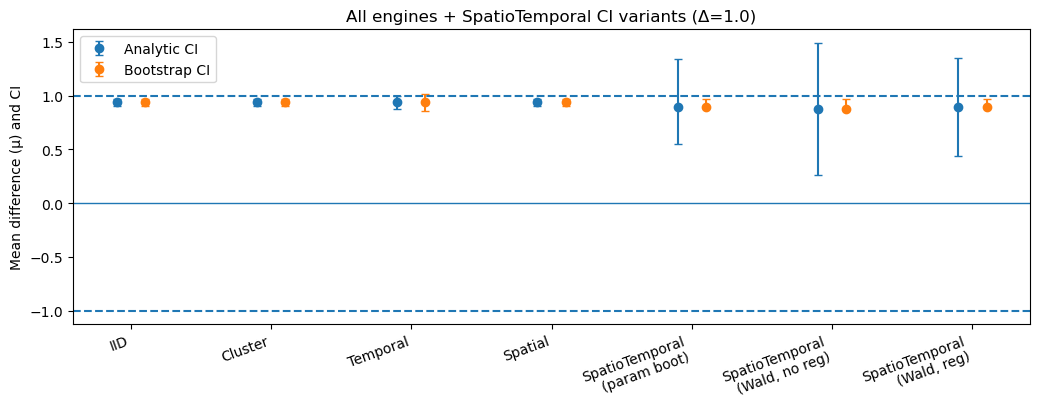

In [17]:
plot_ci_compare_delta1(comb, "All engines + SpatioTemporal CI variants")

## 4) Interpreting results

### How to interpret pyTOST outputs (general)
For each margin \(\Delta\), the primary table reports:
- \(\hat\mu\): estimated mean paired difference
- `ci_low`, `ci_high`: the engine’s CI for \(\mu\) at level \(1-2\alpha\)
- TOST decision: equivalence is supported at margin \(\Delta\) if the CI is **fully contained** in \([-\Delta, +\Delta]\)

Important: a “wider” CI is not automatically worse — it may be *more correct* under dependence.

### How to interpret this demo dataset (specific)
This dataset was generated with nontrivial spatiotemporal dependence, so:
- IID is expected to be the most optimistic (narrowest CI),
- cluster/temporal/spatial should widen relative to IID,
- spatiotemporal should typically be widest (lowest effective sample size).

Use the final plot to compare each engine’s CI against the equivalence band \([-\Delta, +\Delta]\) and check whether the bootstrap sanity checks broadly agree with the analytic/model-based CI.
